# Full-run plotter (crosstab + payload sweep + b-tree)

Reads the four CSVs produced by `run_all_benchmarks.sh` and emits per-workload figures next to the CSVs. Default points at `run_20260520_130223`; edit the config cell to switch runs.

Variant naming for the figures (CSV column → legend label):

| CSV column   | Legend label                  |
|--------------|-------------------------------|
| `LIPAH`      | `LIPAH`                       |
| `PrediCache` | `Uniform-Probe = PrediCache*` |
| `prefix`     | `RelationLocal-Probe`         |
| `bypass`     | `Uniform-Bypass`              |
| `both`       | `RelationLocal-Bypass`        |

In [62]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Match the paper style if present.
_style = Path('custom_plt_style.mplstyle')
if _style.exists():
    plt.style.use(str(_style))
    plt.rcParams['font.serif'] = [
        'Times New Roman', 'Liberation Serif', 'DejaVu Serif', 'serif'
    ]

# CSV column value → display label.
VARIANT_ORDER = ['LIPAH', 'PrediCache', 'prefix', 'bypass', 'both']
LABELS = {
    'LIPAH':      'LIPAH',
    'PrediCache': 'Uniform-Probe = PrediCache*',
    'prefix':     'RelationLocal-Probe',
    'bypass':     'Uniform-Bypass',
    'both':       'RelationLocal-Bypass',
}
COLORS = {
    'LIPAH':      '#0C5DA5',
    'PrediCache': '#00B945',
    'prefix':     '#845B97',
    'bypass':     '#FF9500',
    'both':       '#FF2C00',
}
MARKERS = {
    'LIPAH': 'o', 'PrediCache': 's', 'prefix': 'v', 'bypass': '^', 'both': 'D',
}
HATCHES = {
    'LIPAH': '', 'PrediCache': '//', 'prefix': '\\\\', 'bypass': 'xx', 'both': '..',
}

## Configuration

In [63]:
RUN_DIR = Path('results/run_20260520_130223')
CSV_DIR = RUN_DIR / 'csv'
OUTDIR  = RUN_DIR / 'plots'
OUTDIR.mkdir(parents=True, exist_ok=True)
print('reading CSVs from', CSV_DIR)
print('writing plots to', OUTDIR)

reading CSVs from results/run_20260520_130223/csv
writing plots to results/run_20260520_130223/plots


In [64]:
def load_csv(name):
    p = CSV_DIR / name
    if not p.exists():
        print(f'  missing: {p}')
        return None
    df = pd.read_csv(p)
    print(f'  loaded {name}: {len(df)} rows')
    return df

crosstab    = load_csv('crosstab_44t.csv')
payload_sat = load_csv('seq_payload_sat.csv')
payload_stl = load_csv('seq_payload_stale.csv')
btree_get   = load_csv('btree_get.csv')
btree_scan  = load_csv('btree_range_scan.csv')

# Filter to the variants we know about (in case the CSV has extras).
def keep_variants(df):
    if df is None:
        return None
    return df[df.variant.isin(VARIANT_ORDER)].copy()

crosstab    = keep_variants(crosstab)
payload_sat = keep_variants(payload_sat)
payload_stl = keep_variants(payload_stl)
btree_get   = keep_variants(btree_get)
btree_scan  = keep_variants(btree_scan)

  loaded crosstab_44t.csv: 60 rows
  loaded seq_payload_sat.csv: 75 rows
  loaded seq_payload_stale.csv: 75 rows
  loaded btree_get.csv: 15 rows
  loaded btree_range_scan.csv: 15 rows


## Crosstab (44 threads × {sequential, uniform} × {sat, stale})

Grouped bar chart, two access modes (sequential vs uniform), two states (sat vs stale), one bar per variant per cell. Output: `crosstab_44t.{png,pdf}`.

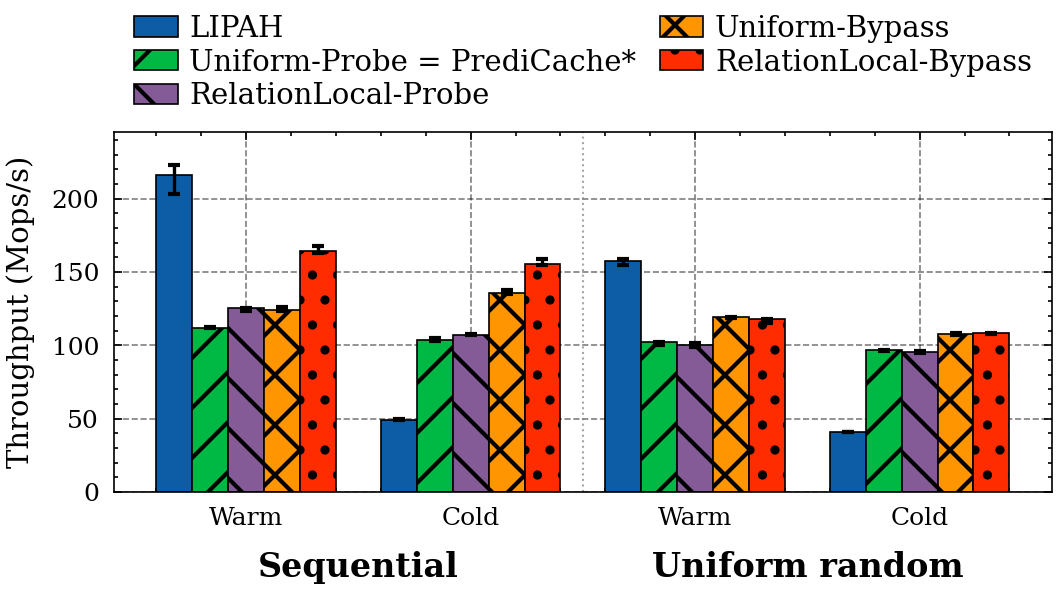

  wrote results/run_20260520_130223/plots/crosstab_44t.png and .pdf


In [65]:
df = crosstab.copy()
# Median + min/max across trials.
g = (
    df.groupby(['variant', 'access', 'state'])
      .mops.agg(['median', 'min', 'max'])
      .reset_index()
)

scenarios = [
    ('sequential', 'sat',   'Warm'),
    ('sequential', 'stale', 'Cold'),
    ('uniform',    'sat',   'Warm'),
    ('uniform',    'stale', 'Cold'),
]

n_var  = len(VARIANT_ORDER)
bar_w  = 0.8 / n_var
center = (n_var - 1) / 2.0
xs     = list(range(len(scenarios)))

fig, ax = plt.subplots(figsize=(3.4, 2.0))
for i, v in enumerate(VARIANT_ORDER):
    ys, elo, ehi = [], [], []
    for access, state, _label in scenarios:
        row = g[(g.variant == v) & (g.access == access) & (g.state == state)]
        if row.empty:
            ys.append(0.0); elo.append(0.0); ehi.append(0.0)
            continue
        m  = row['median'].iloc[0]
        lo = row['min'].iloc[0]
        hi = row['max'].iloc[0]
        ys.append(m); elo.append(m - lo); ehi.append(hi - m)
    offsets = [x + (i - center) * bar_w for x in xs]
    ax.bar(
        offsets, ys, bar_w,
        label=LABELS[v], color=COLORS[v],
        yerr=[elo, ehi], capsize=1.5,
        edgecolor='black', linewidth=0.4,
        hatch=HATCHES[v],
    )

# Leaf labels under each bar group.
ax.set_xticks(xs)
ax.set_xticklabels([s[2] for s in scenarios])
ax.set_ylabel('Throughput (Mops/s)')

# Group labels (Sequential / Uniform random) under the leaf labels.
ymax = max(ys) if g.empty else g['max'].max()
for cx, lbl in zip([0.5, 2.5], ['Sequential', 'Uniform random']):
    ax.text(cx, -ymax * 0.18, lbl, ha='center', va='top',
            fontsize=8, fontweight='bold')
ax.axvline(x=1.5, color='0.5', linestyle=':', linewidth=0.5, alpha=0.7)
ax.set_ylim(0, ymax * 1.1)

ax.legend(
    loc='lower center', bbox_to_anchor=(0.5, 1.02),
    ncol=2, fontsize=7, frameon=False,
    handlelength=1.5, handletextpad=0.4,
    borderpad=0.3, columnspacing=0.8,
)
fig.subplots_adjust(left=0.07, right=0.99, top=0.82, bottom=0.22)
fig.savefig(OUTDIR / 'crosstab_44t.png', dpi=160)
fig.savefig(OUTDIR / 'crosstab_44t.pdf')
plt.show()
print(f'  wrote {OUTDIR / "crosstab_44t.png"} and .pdf')

## Sequential payload sweep — sat + stale (side-by-side)

Two-panel line plot, x = payload bytes (log), y = Mops/s, one line per variant. Output: `seq_payload.{png,pdf}`.

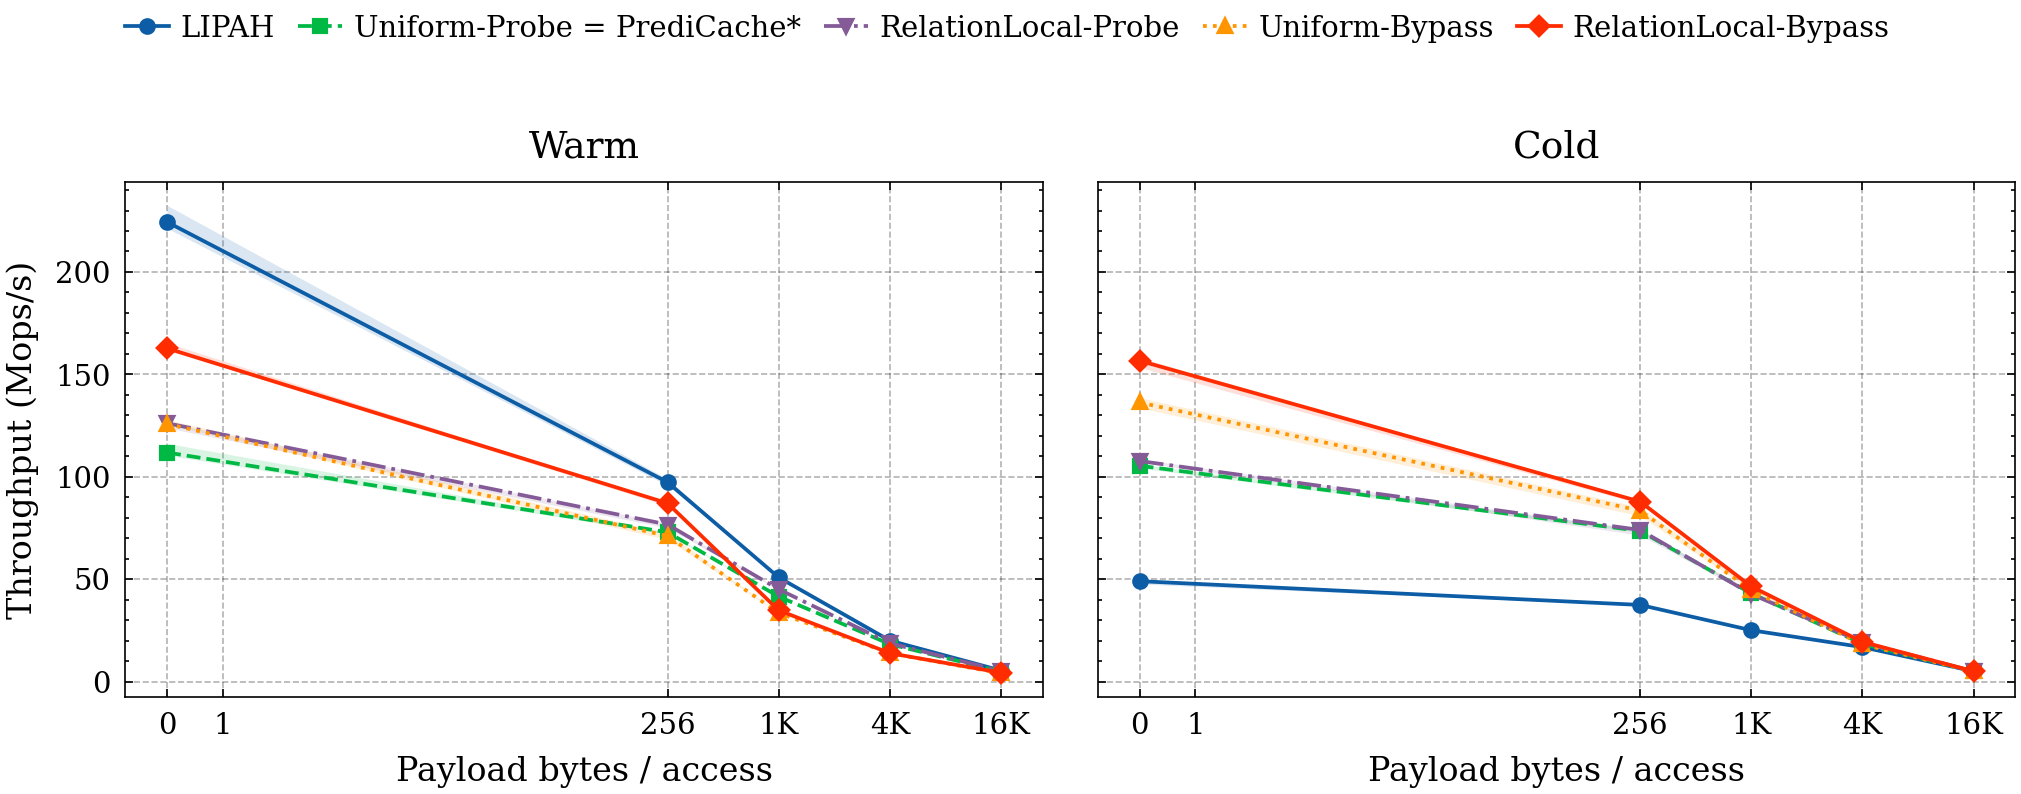

  wrote results/run_20260520_130223/plots/seq_payload.png and .pdf


In [66]:
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.6), sharey=True)
for ax, df, panel_title in [
    (axes[0], payload_sat, 'Warm'),
    (axes[1], payload_stl, 'Cold'),
]:
    if df is None or df.empty:
        ax.set_title(panel_title)
        ax.axis('off')
        continue
    g_pay = (
        df.groupby(['variant', 'payload_bytes'])
          .mops.agg(['median', 'min', 'max'])
          .reset_index()
    )
    for v in VARIANT_ORDER:
        sub = g_pay[g_pay.variant == v].sort_values('payload_bytes').copy()
        if sub.empty:
            continue
        # 0 doesn't fit on log scale — place at 0.5 with a labelled '0' tick.
        x = sub.payload_bytes.replace(0, 0.5)
        ax.plot(
            x, sub['median'],
            label=LABELS[v], color=COLORS[v], marker=MARKERS[v],
            markersize=3, linewidth=0.9,
        )
        ax.fill_between(
            x, sub['min'], sub['max'],
            color=COLORS[v], alpha=0.15, linewidth=0,
        )
    ax.set_xscale('log')
    ax.set_xticks([0.5, 1, 256, 1024, 4096, 16384])
    ax.set_xticklabels(['0', '1', '256', '1K', '4K', '16K'])
    ax.tick_params(axis='x', which='minor', bottom=False, top=False)
    ax.set_xlabel('Payload bytes / access', fontsize=8)
    ax.set_title(panel_title, fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=7)
axes[0].set_ylabel('Throughput (Mops/s)', fontsize=8)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center', bbox_to_anchor=(0.5, 1.02),
    ncol=len(VARIANT_ORDER), fontsize=7, frameon=False,
    handlelength=1.5, handletextpad=0.4,
    borderpad=0.3, columnspacing=0.8,
)
fig.subplots_adjust(left=0.08, right=0.98, top=0.86, bottom=0.20, wspace=0.06)
fig.savefig(OUTDIR / 'seq_payload.png', dpi=160)
fig.savefig(OUTDIR / 'seq_payload.pdf')
plt.show()
print(f'  wrote {OUTDIR / "seq_payload.png"} and .pdf')

## B-tree random GET

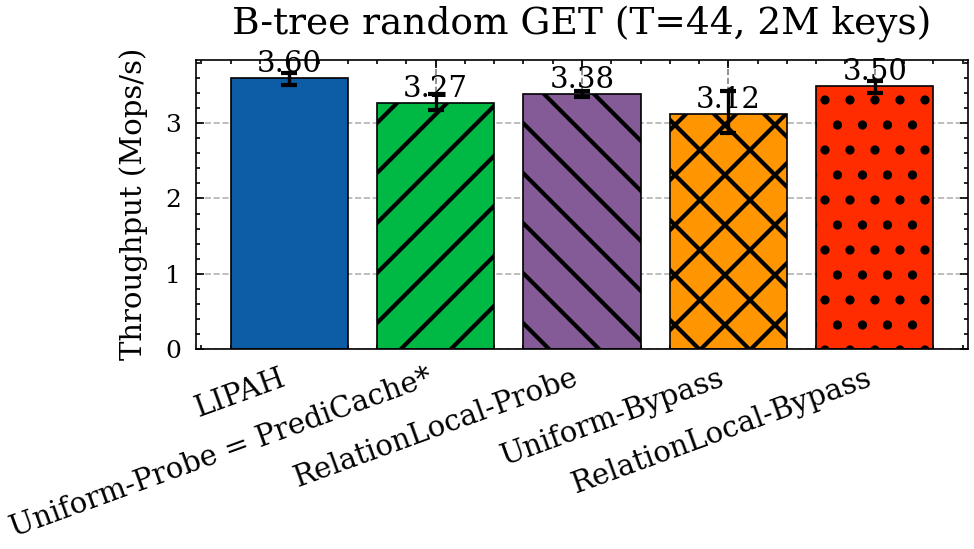

  wrote results/run_20260520_130223/plots/btree_get.png and .pdf


In [67]:
def bar_one_metric(df, metric_col, ylabel, fname, title=None):
    if df is None or df.empty:
        print(f'  skipping {fname}: no data')
        return
    g = (
        df.groupby('variant')[metric_col].agg(['mean', 'min', 'max'])
          .reindex(VARIANT_ORDER)
          .reset_index()
    )
    fig, ax = plt.subplots(figsize=(3.4, 2.0))
    xs = list(range(len(VARIANT_ORDER)))
    means = g['mean'].values
    elo = (g['mean'] - g['min']).values
    ehi = (g['max'] - g['mean']).values
    ax.bar(
        xs, means,
        color=[COLORS[v] for v in VARIANT_ORDER],
        yerr=[elo, ehi], capsize=2.0,
        edgecolor='black', linewidth=0.4,
        hatch=[HATCHES[v] for v in VARIANT_ORDER],
    )
    for x, m in zip(xs, means):
        if pd.isna(m):
            continue
        ax.text(x, m, f'{m:.2f}', ha='center', va='bottom', fontsize=7)
    ax.set_xticks(xs)
    ax.set_xticklabels([LABELS[v] for v in VARIANT_ORDER], rotation=20, ha='right', fontsize=7)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title, fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)
    fig.tight_layout()
    fig.savefig(OUTDIR / f'{fname}.png', dpi=160)
    fig.savefig(OUTDIR / f'{fname}.pdf')
    plt.show()
    print(f'  wrote {OUTDIR / fname}.png and .pdf')

bar_one_metric(btree_get, 'mops', 'Throughput (Mops/s)', 'btree_get',
               title='B-tree random GET (T=44, 2M keys)')

## B-tree random-start range scan

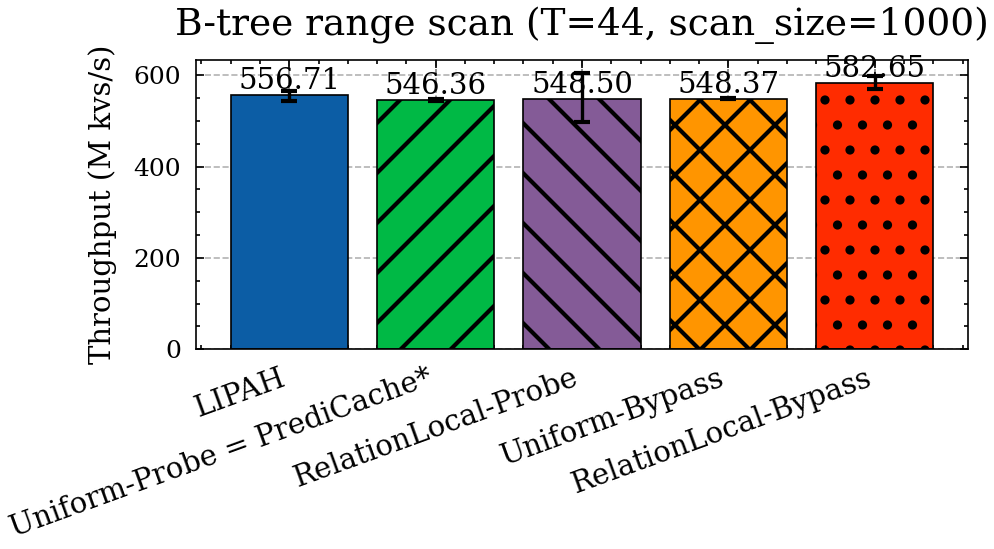

  wrote results/run_20260520_130223/plots/btree_range_scan.png and .pdf


In [68]:
bar_one_metric(btree_scan, 'mkvs_per_s', 'Throughput (M kvs/s)', 'btree_range_scan',
               title=f'B-tree range scan (T=44, scan_size=1000)')

## B-tree GET + range scan side by side

Single figure with both b-tree workloads, shared legend on top. Useful as the
combined b-tree result for the paper. Output: `btree_side_by_side.{png,pdf}`.


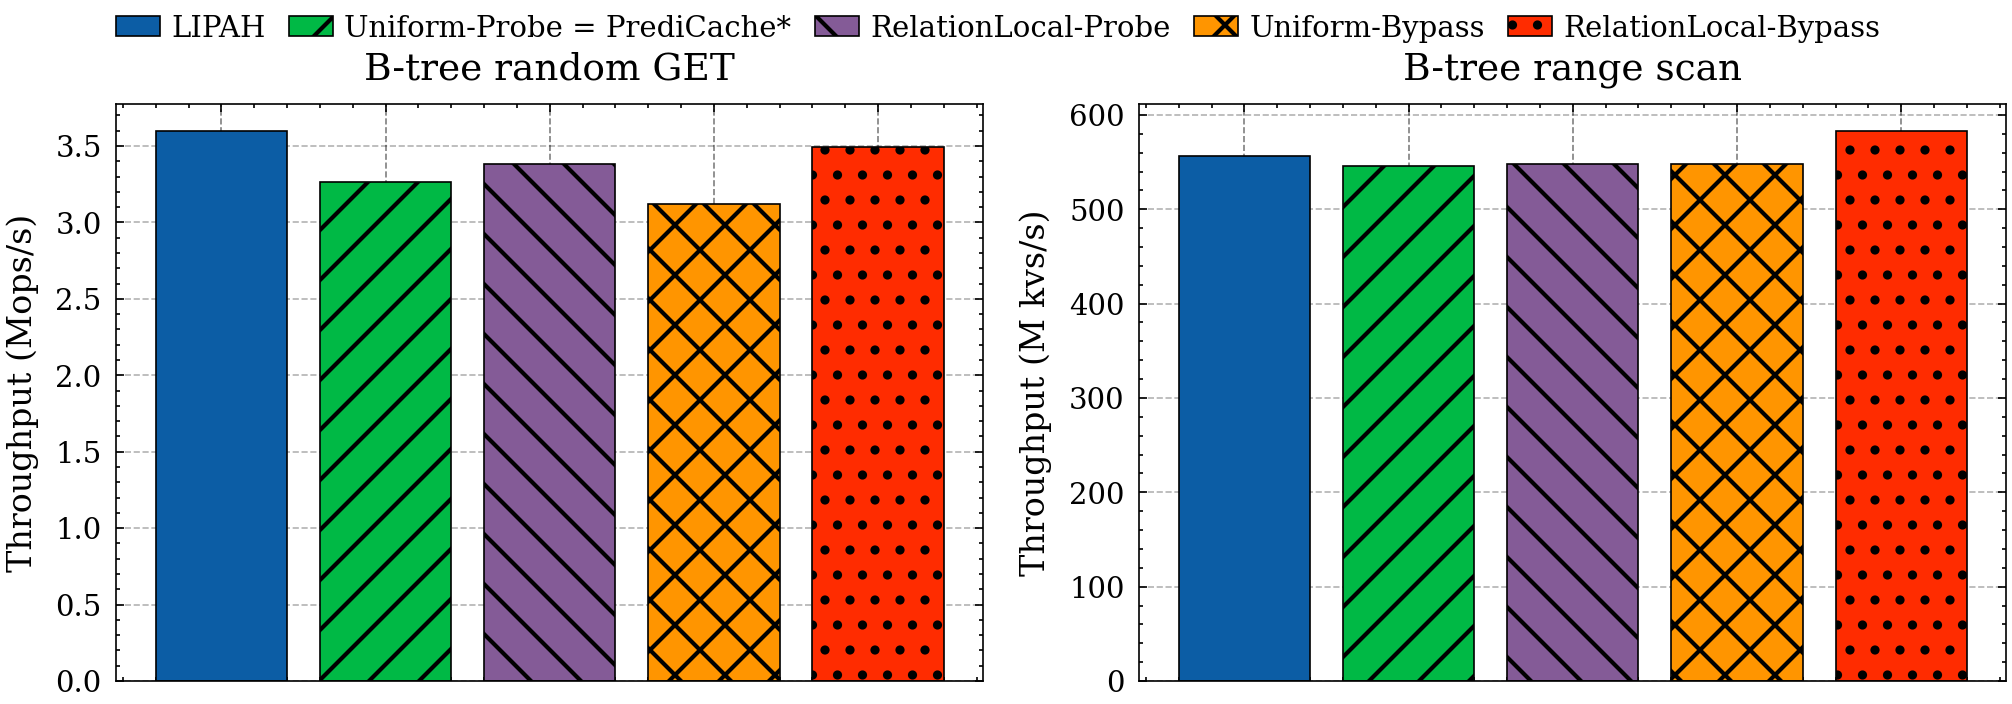

  wrote results/run_20260520_130223/plots/btree_side_by_side.png and .pdf


In [74]:
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.6))

def _bar(ax, df, metric_col, ylabel, title):
    if df is None or df.empty:
        ax.axis('off')
        return
    means = (df.groupby('variant')[metric_col].mean()
                .reindex(VARIANT_ORDER).values)
    xs = list(range(len(VARIANT_ORDER)))
    for i, v in enumerate(VARIANT_ORDER):
        if pd.isna(means[i]):
            continue
        ax.bar(
            [i], [means[i]],
            color=COLORS[v], hatch=HATCHES[v],
            edgecolor='black', linewidth=0.4,
            label=LABELS[v],
        )
    ax.set_xticks(xs)
    ax.set_xticklabels([])
    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)
    ax.tick_params(labelsize=7)

_bar(axes[0], btree_get,  'mops',       'Throughput (Mops/s)', 'B-tree random GET')
_bar(axes[1], btree_scan, 'mkvs_per_s', 'Throughput (M kvs/s)', 'B-tree range scan')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center', bbox_to_anchor=(0.5, 0.9),
    ncol=len(VARIANT_ORDER), fontsize=7, frameon=False,
    handlelength=1.5, handletextpad=0.4,
    borderpad=0.3, columnspacing=0.8,
)
fig.subplots_adjust(left=0.08, right=0.98, top=0.84, bottom=0.10, wspace=0.18)
fig.savefig(OUTDIR / 'btree_side_by_side.png', dpi=330)
fig.savefig(OUTDIR / 'btree_side_by_side.pdf')
plt.show()
print(f'  wrote {OUTDIR / "btree_side_by_side.png"} and .pdf')

## Sanity tables

Per-variant medians for each workload.

In [70]:
if crosstab is not None and not crosstab.empty:
    pivot = (
        crosstab.groupby(['variant', 'access', 'state'])
                .mops.median()
                .unstack(['access', 'state'])
                .reindex(VARIANT_ORDER)
                .round(2)
    )
    display(pivot)
else:
    print('no crosstab data')

access     sequential         uniform        
state             sat   stale     sat   stale
variant                                      
LIPAH          216.43   49.29  157.35   41.21
PrediCache     111.67  103.86  102.22   96.78
prefix         125.54  107.43  100.46   95.59
bypass         124.24  135.85  119.39  107.61
both           164.22  155.70  117.68  108.51

In [71]:
for df, label in [(payload_sat, 'seq_payload_sat'), (payload_stl, 'seq_payload_stale')]:
    if df is None or df.empty:
        continue
    pivot = (
        df.groupby(['variant', 'payload_bytes'])
          .mops.median()
          .unstack('payload_bytes')
          .reindex(VARIANT_ORDER)
          .round(2)
    )
    print(label)
    display(pivot)

seq_payload_sat


payload_bytes,0,256,1024,4096,16384
variant,,,,,
LIPAH,224.38,97.34,50.84,20.01,5.37
PrediCache,111.85,72.91,41.50,18.26,4.89
prefix,126.14,76.68,45.05,18.72,5.17
bypass,125.77,71.09,33.50,13.85,4.05
both,162.70,87.08,34.78,13.86,4.32


seq_payload_stale


payload_bytes,0,256,1024,4096,16384
variant,,,,,
LIPAH,49.04,37.44,25.07,16.83,5.04
PrediCache,105.40,73.56,43.05,18.45,4.97
prefix,107.70,74.04,42.74,19.13,5.03
bypass,136.28,83.47,44.55,18.17,4.96
both,156.67,87.88,46.46,19.38,5.04


In [72]:
for df, metric, label in [
    (btree_get,  'mops',       'btree_get (Mops/s)'),
    (btree_scan, 'mkvs_per_s', 'btree_range_scan (M kvs/s)'),
]:
    if df is None or df.empty:
        continue
    snap = (
        df.groupby('variant')[metric].agg(['mean', 'min', 'max'])
          .reindex(VARIANT_ORDER)
          .round(2)
    )
    print(label)
    display(snap)

btree_get (Mops/s)


,mean,min,max
variant,,,
LIPAH,3.60,3.50,3.66
PrediCache,3.27,3.17,3.38
prefix,3.38,3.35,3.42
bypass,3.12,2.87,3.42
both,3.50,3.40,3.56


btree_range_scan (M kvs/s)


,mean,min,max
variant,,,
LIPAH,556.71,544.74,565.06
PrediCache,546.36,542.75,548.82
prefix,548.50,498.90,604.51
bypass,548.37,547.43,550.12
both,582.65,569.23,599.56
